# JOIN Benchmark Script

This notebook runs the join_benchmark binary and visualizes the results as stacked bar charts.

## Configuration

In [155]:
# Benchmark configuration
SCALE_FACTOR = "0.01"  # TPC-H scale factor
UPDATE_PCT = "1"       # Update percentage
REPEATS = 1            # Number of times to repeat each benchmark
TABLE_TYPES = ["chain", "heap", "ts-partitioned", "naive"]  # Table types to benchmark

# Paths (relative to notebook location: benches/sigmod/join_benchmark/)
BENCHMARK_BINARY = "./target/release/join_benchmark"
TPCH_DATA_DIR = "../tpch_data"  # benches/sigmod/tpch_data
GENERATE_SCRIPT = "./generate_data.sh"  # benches/sigmod/generate_data.sh

# CLI arguments for data file paths (relative to project root where binary runs)
DATA_DIR = "benches/sigmod/tpch_data"

In [156]:
import subprocess
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Patch
import glob
import shutil

## Data Generation

Clear existing .tbl files and regenerate with specified scale factor and update percentage.

In [157]:
def clear_tbl_files():
    """Remove all .tbl files from tpch_data directory."""
    tbl_files = glob.glob(os.path.join(TPCH_DATA_DIR, "*.tbl"))
    for f in tbl_files:
        os.remove(f)
        print(f"Removed: {f}")
    print(f"Cleared {len(tbl_files)} .tbl files")

clear_tbl_files()

Removed: ../tpch_data/part_sf0.01.tbl
Removed: ../tpch_data/lineitem_sf0.1.tbl
Removed: ../tpch_data/part_updates_sf0.01_1pct_uniform.tbl
Removed: ../tpch_data/part_sf0.1.tbl
Removed: ../tpch_data/lineitem_sf0.01.tbl
Removed: ../tpch_data/part_updated_sf0.01_1pct_zipf0.99.tbl
Removed: ../tpch_data/part_updated_sf0.1_1pct_uniform.tbl
Removed: ../tpch_data/part_updates_sf0.1_1pct_uniform.tbl
Removed: ../tpch_data/part_updates_sf0.1_1pct_zipf0.99.tbl
Removed: ../tpch_data/part_updated_sf0.01_1pct_uniform.tbl
Removed: ../tpch_data/part_updates_sf0.01_1pct_zipf0.99.tbl
Removed: ../tpch_data/part_updated_sf0.1_1pct_zipf0.99.tbl
Cleared 12 .tbl files


In [158]:
def generate_data(sf, update_pct):
    """Generate TPC-H data using generate_data.sh script."""
    print(f"=== Generating TPC-H data (SF={sf}, Update={update_pct}%) ===")
    
    cmd = [f"./{GENERATE_SCRIPT}", sf, update_pct]
    print(f"Running: {' '.join(cmd)}")
    
    # Run from sigmod directory
    result = subprocess.run(cmd, capture_output=True, text=True, cwd="../")
    
    if result.returncode != 0:
        print(f"Error generating data: {result.stderr}")
        return False
    
    print(result.stdout)
    
    # List generated files
    tbl_files = glob.glob(os.path.join(TPCH_DATA_DIR, "*.tbl"))
    print(f"\nGenerated {len(tbl_files)} files:")
    for f in sorted(tbl_files):
        size = os.path.getsize(f)
        print(f"  {f}: {size / 1024 / 1024:.2f} MB")
    
    return True

generate_data(SCALE_FACTOR, UPDATE_PCT)

=== Generating TPC-H data (SF=0.01, Update=1%) ===
Running: ././generate_data.sh 0.01 1
=== Building dbgen ===
=== Generating TPC-H tables (SF=0.01) ===
=== Generating updates (1% uniform) ===
Total rows:      2000
Update ops:      20 (1%)
Unique keys hit: 20
Distribution:    uniform
Updates file:    /home/zhi/codebase/FosterBtree/benches/sigmod/tpch_data/part_updates_sf0.01_1pct_uniform.tbl
Updated table:   /home/zhi/codebase/FosterBtree/benches/sigmod/tpch_data/part_updated_sf0.01_1pct_uniform.tbl
=== Generating updates (1% zipf0.99) ===
Total rows:      2000
Update ops:      20 (1%)
Unique keys hit: 13
Distribution:    zipf0.99
Updates file:    /home/zhi/codebase/FosterBtree/benches/sigmod/tpch_data/part_updates_sf0.01_1pct_zipf0.99.tbl
Updated table:   /home/zhi/codebase/FosterBtree/benches/sigmod/tpch_data/part_updated_sf0.01_1pct_zipf0.99.tbl
=== Done ===
-rw-rw-r-- 1 zhi zhi 7.0M Mar 11 09:36 /home/zhi/codebase/FosterBtree/benches/sigmod/tpch_data/lineitem_sf0.01.tbl
-rw-rw-r-- 

True

## Build Benchmark Binary

In [159]:
def build_benchmark():
    """Build the join_benchmark binary in release mode."""
    print("=== Building Rust binary in release mode ===")
    
    result = subprocess.run(
        ["cargo", "build", "--release", "--bin", "join_benchmark"],
        capture_output=True,
        text=True
    )
    
    if result.returncode != 0:
        print(f"Build failed: {result.stderr}")
        return False
    
    print("Cargo build completed successfully.")
    return True

build_benchmark()

=== Building Rust binary in release mode ===
Cargo build completed successfully.


True

## Run Benchmarks

Parse benchmark output to extract timing information.

In [160]:
def parse_benchmark_output(output, table_type):
    """Parse benchmark output to extract timing data."""
    results = []
    
    # Patterns to match timing output
    build_pattern = r"Insert time: ([\d.]+)(ms|s|µs|us)"
    probe_pattern = r"Probe time: ([\d.]+)(ms|s|µs|us)"
    update_pattern = r"Update time: ([\d.]+)(ms|s|µs|us)"
    repair_type_pattern = r"=== (No Repair|Read Repair|Write Repair) ==="
    
    current_repair_type = "No Repair"
    
    def parse_time(value, unit):
        """Convert time value to milliseconds."""
        value = float(value)
        if unit == 's':
            return value * 1000  # seconds to ms
        elif unit == 'ms':
            return value  # already in ms
        elif unit in ['µs', 'us']:  # µs (microseconds) or us (alternative)
            return value / 1000  # microseconds to ms
        return value
    
    # For naive table type, we need to accumulate build times (initial + rebuild)
    is_naive = table_type == "naive"
    build_time_accumulator = 0
    
    for line in output.split('\n'):
        # Check for repair type
        repair_match = re.search(repair_type_pattern, line)
        if repair_match:
            current_repair_type = repair_match.group(1)
            continue
        
        # Check for build time
        build_match = re.search(build_pattern, line)
        if build_match:
            value = parse_time(build_match.group(1), build_match.group(2))
            if is_naive:
                # Accumulate build times for naive (initial + rebuild)
                build_time_accumulator += value
                print(f"hahahaha accumulator now is {build_time_accumulator} value is {value}")
            elif not any(r['repair_type'] == current_repair_type and r['metric'] == 'build' for r in results):
                # For non-naive, only capture first occurrence per repair type
                results.append({
                    'repair_type': current_repair_type,
                    'metric': 'build',
                    'duration_ms': value
                })
            continue
        

        
        # Check for update time
        update_match = re.search(update_pattern, line)
        if update_match and not any(r['repair_type'] == current_repair_type and r['metric'] == 'update' for r in results):
            value = parse_time(update_match.group(1), update_match.group(2))
            results.append({
                'repair_type': current_repair_type,
                'metric': 'update',
                'duration_ms': value
            })
            continue
        
        # Check for probe time (capture both probes, use the second one after updates)
        probe_match = re.search(probe_pattern, line)
        if probe_match:
            value = parse_time(probe_match.group(1), probe_match.group(2))
            # For probe, we want the one after updates (Phase 4 or Phase 5)
            # Skip the first probe (Phase 2) and keep the second one
            existing_probes = [r for r in results if r['repair_type'] == current_repair_type and r['metric'] == 'probe']
            if len(existing_probes) >= 1:
                # Replace the existing probe with the new one (after updates)
                results = [r for r in results if not (r['repair_type'] == current_repair_type and r['metric'] == 'probe')]
            results.append({
                'repair_type': current_repair_type,
                'metric': 'probe',
                'duration_ms': value
            })
    # For naive: when we encounter the second probe (Phase 5), save accumulated build time
    if is_naive and build_time_accumulator > 0:
        # probe_match_check = re.search(probe_pattern, line)
        # if probe_match_check and not any(r['repair_type'] == current_repair_type and r['metric'] == 'build' for r in results):
            # This is the second probe (after rebuild), save accumulated build time
        results.append({
            'repair_type': current_repair_type,
            'metric': 'build',
            'duration_ms': build_time_accumulator
        })
        build_time_accumulator = 0  # Reset for next repair type
    return results

In [161]:
def run_benchmark(table_type, repeat_idx):
    """Run benchmark for a specific table type and repeat."""
    # Pass explicit file paths to the binary
    cmd = [
        BENCHMARK_BINARY,
        "--table-type", table_type,
        "--part-file", f"{DATA_DIR}/part_sf{SCALE_FACTOR}.tbl",
        "--part-updates-file", f"{DATA_DIR}/part_updates_sf{SCALE_FACTOR}_{UPDATE_PCT}pct_uniform.tbl",
        "--part-updated-file", f"{DATA_DIR}/part_updated_sf{SCALE_FACTOR}_{UPDATE_PCT}pct_uniform.tbl",
        "--lineitem-file", f"{DATA_DIR}/lineitem_sf{SCALE_FACTOR}.tbl",
    ]
    
    print(f"   - Trail {repeat_idx + 1}/{REPEATS}")
    print(f"Running: {' '.join(cmd)}")
    
    result = subprocess.run(cmd, capture_output=True, text=True, cwd="../../../")  # Run from project root
    
    if result.returncode != 0:
        print(f"Error: {result.stderr}")
        return None
    
    return parse_benchmark_output(result.stdout, table_type)

In [162]:
def run_all_benchmarks():
    """Run all benchmarks and collect results."""
    all_results = []
    
    for table_type in TABLE_TYPES:
        print(f"\n{'='*60}")
        print(f"Running for table_type={table_type} with {REPEATS} repeats...")
        print(f"{'='*60}")
        
        for repeat_idx in range(REPEATS):
            results = run_benchmark(table_type, repeat_idx)
            
            if results:
                for r in results:
                    r['table_type'] = table_type
                    r['repeat'] = repeat_idx
                all_results.extend(results)
    
    return all_results

raw_results = run_all_benchmarks()
print(f"\nCollected {len(raw_results)} timing results")


Running for table_type=chain with 1 repeats...
   - Trail 1/1
Running: ./target/release/join_benchmark --table-type chain --part-file benches/sigmod/tpch_data/part_sf0.01.tbl --part-updates-file benches/sigmod/tpch_data/part_updates_sf0.01_1pct_uniform.tbl --part-updated-file benches/sigmod/tpch_data/part_updated_sf0.01_1pct_uniform.tbl --lineitem-file benches/sigmod/tpch_data/lineitem_sf0.01.tbl

Running for table_type=heap with 1 repeats...
   - Trail 1/1
Running: ./target/release/join_benchmark --table-type heap --part-file benches/sigmod/tpch_data/part_sf0.01.tbl --part-updates-file benches/sigmod/tpch_data/part_updates_sf0.01_1pct_uniform.tbl --part-updated-file benches/sigmod/tpch_data/part_updated_sf0.01_1pct_uniform.tbl --lineitem-file benches/sigmod/tpch_data/lineitem_sf0.01.tbl

Running for table_type=ts-partitioned with 1 repeats...
   - Trail 1/1
Running: ./target/release/join_benchmark --table-type ts-partitioned --part-file benches/sigmod/tpch_data/part_sf0.01.tbl --part

In [163]:
# Convert to DataFrame and aggregate
df = pd.DataFrame(raw_results)

# Group by table_type, repair_type, and metric, then calculate mean
agg_df = df.groupby(['table_type', 'repair_type', 'metric'])['duration_ms'].mean().reset_index()

# Pivot to get wide format for stacked bar chart
pivot_df = agg_df.pivot_table(
    index=['table_type', 'repair_type'],
    columns='metric',
    values='duration_ms',
    fill_value=0
).reset_index()

print("\nAggregated results (mean duration in ms):")
print(pivot_df.to_string())


Aggregated results (mean duration in ms):
metric      table_type   repair_type     build      probe    update
0                chain     No Repair  0.302971  17.928025  0.011848
1                chain   Read Repair  0.298553  18.577903  0.010828
2                chain  Write Repair  0.288570  17.849771  0.009406
3                 heap     No Repair  0.315302  17.006789  0.005665
4                 heap   Read Repair  0.310887  17.416652  0.006150
5                 heap  Write Repair  0.313628  17.265727  0.007234
6                naive     No Repair  0.548445  15.715726  0.000000
7       ts-partitioned     No Repair  0.344111  21.247727  0.005969
8       ts-partitioned   Read Repair  0.329797  21.323697  0.005185
9       ts-partitioned  Write Repair  0.303627  20.711003  0.006743


In [164]:
df

,repair_type,metric,duration_ms,table_type,repeat
0,No Repair,build,0.302971,chain,0
1,No Repair,update,0.011848,chain,0
2,No Repair,probe,17.928025,chain,0
3,Read Repair,build,0.298553,chain,0
4,Read Repair,update,0.010828,chain,0
5,Read Repair,probe,18.577903,chain,0
6,Write Repair,build,0.288570,chain,0
7,Write Repair,update,0.009406,chain,0
8,Write Repair,probe,17.849771,chain,0
9,No Repair,build,0.315302,heap,0


## Visualization

Create stacked bar chart showing build, update, and probe times.

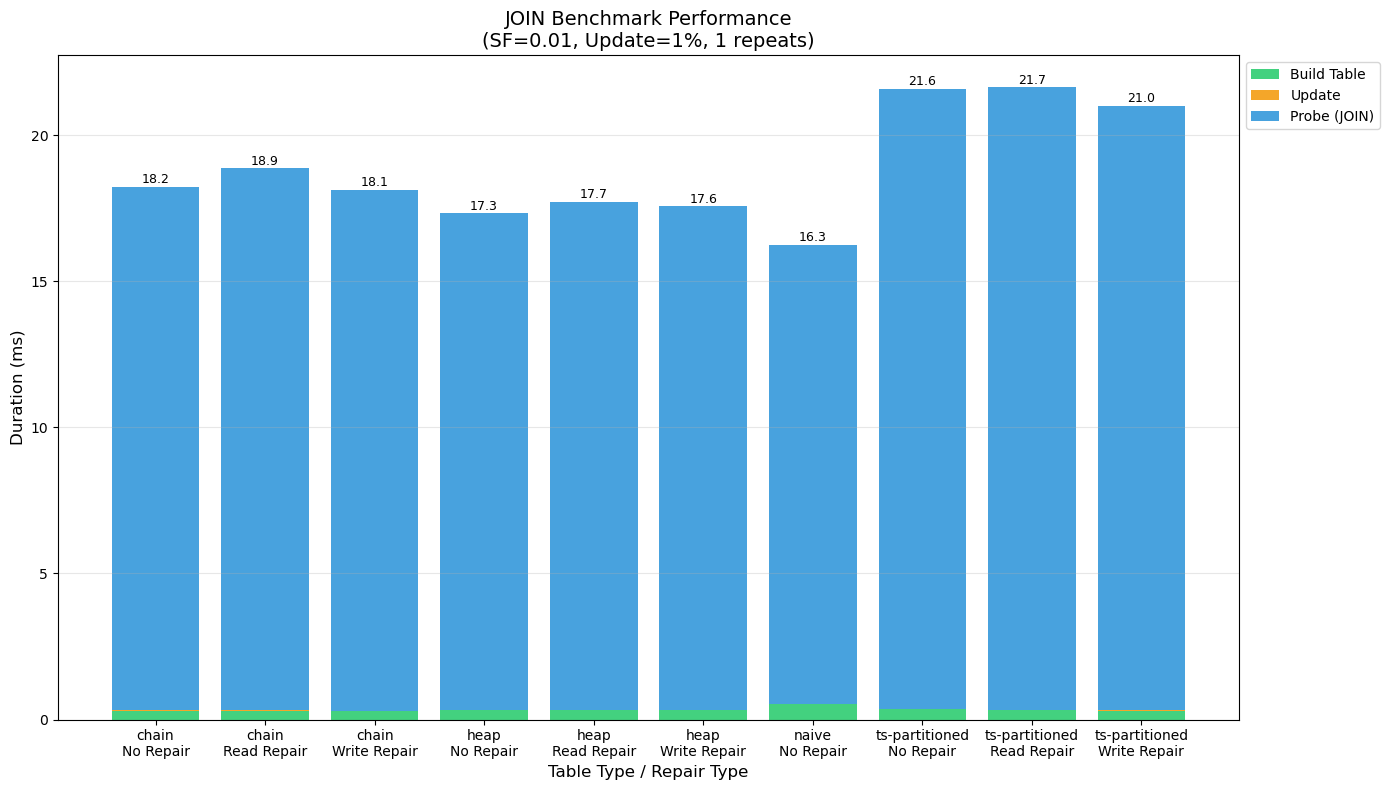


Chart saved to join_benchmark_results.png


In [165]:
# Create stacked bar chart
fig, ax = plt.subplots(figsize=(14, 8))

# Prepare data for plotting
x_labels = []
build_times = []
update_times = []
probe_times = []

for _, row in pivot_df.iterrows():
    label = f"{row['table_type']}\n{row['repair_type']}"
    x_labels.append(label)
    build_times.append(row['build'])
    update_times.append(row['update'])
    probe_times.append(row['probe'])

x_pos = range(len(x_labels))

# Create stacked bars
ax.bar(x_pos, build_times, label='Build Table', color='#2ecc71', alpha=0.9)
ax.bar(x_pos, update_times, bottom=build_times, label='Update', color='#f39c12', alpha=0.9)
ax.bar(x_pos, probe_times, bottom=[b+u for b, u in zip(build_times, update_times)], label='Probe (JOIN)', color='#3498db', alpha=0.9)

# Customize chart
ax.set_xlabel('Table Type / Repair Type', fontsize=12)
ax.set_ylabel('Duration (ms)', fontsize=12)
ax.set_title(f'JOIN Benchmark Performance\n(SF={SCALE_FACTOR}, Update={UPDATE_PCT}%, {REPEATS} repeats)', fontsize=14)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, rotation=0, fontsize=10)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, (b, u, p) in enumerate(zip(build_times, update_times, probe_times)):
    total = b + u + p
    ax.text(i, total + max(build_times) * 0.02, f'{total:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
# plt.savefig('join_benchmark_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved to join_benchmark_results.png")

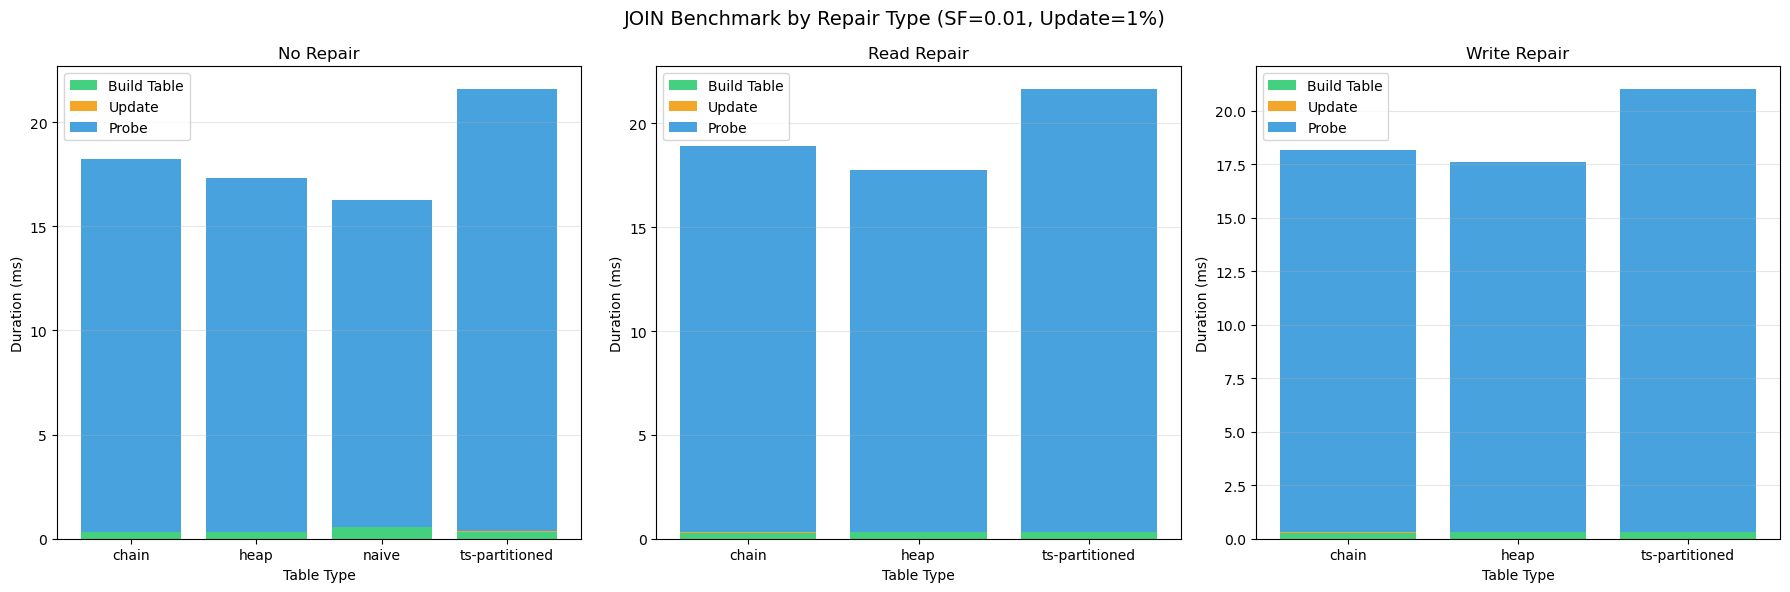

Chart saved to join_benchmark_by_repair.png


In [168]:
# Create separate bar charts for each repair type
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

repair_types = ['No Repair', 'Read Repair', 'Write Repair']
colors = {'build': '#2ecc71', 'update': '#f39c12', 'probe': '#3498db'}

for ax, repair_type in zip(axes, repair_types):
    subset = pivot_df[pivot_df['repair_type'] == repair_type]
    
    x_pos = range(len(subset))
    x_labels = subset['table_type'].tolist()
    
    build_times = subset['build'].tolist()
    update_times = subset['update'].tolist()
    probe_times = subset['probe'].tolist()
    
    ax.bar(x_pos, build_times, label='Build Table', color=colors['build'], alpha=0.9)
    ax.bar(x_pos, update_times, bottom=build_times, label='Update', color=colors['update'], alpha=0.9)
    ax.bar(x_pos, probe_times, bottom=[b+u for b, u in zip(build_times, update_times)], label='Probe', color=colors['probe'], alpha=0.9)
    
    ax.set_xlabel('Table Type')
    ax.set_ylabel('Duration (ms)')
    ax.set_title(f'{repair_type}')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x_labels)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle(f'JOIN Benchmark by Repair Type (SF={SCALE_FACTOR}, Update={UPDATE_PCT}%)', fontsize=14)
plt.tight_layout()
# plt.savefig('join_benchmark_by_repair.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved to join_benchmark_by_repair.png")

## Summary Statistics

In [167]:
# Calculate total time for each combination
pivot_df['total_ms'] = pivot_df['build'] + pivot_df['update'] + pivot_df['probe']

# Find fastest and slowest
fastest = pivot_df.loc[pivot_df['total_ms'].idxmin()]
slowest = pivot_df.loc[pivot_df['total_ms'].idxmax()]

print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"\nFastest configuration:")
print(f"  Table Type: {fastest['table_type']}")
print(f"  Repair Type: {fastest['repair_type']}")
print(f"  Total Time: {fastest['total_ms']:.2f} ms")
print(f"    - Build: {fastest['build']:.2f} ms")
print(f"    - Update: {fastest['update']:.2f} ms")
print(f"    - Probe: {fastest['probe']:.2f} ms")

print(f"\nSlowest configuration:")
print(f"  Table Type: {slowest['table_type']}")
print(f"  Repair Type: {slowest['repair_type']}")
print(f"  Total Time: {slowest['total_ms']:.2f} ms")
print(f"    - Build: {slowest['build']:.2f} ms")
print(f"    - Update: {slowest['update']:.2f} ms")
print(f"    - Probe: {slowest['probe']:.2f} ms")

print(f"\nSpeedup (slowest / fastest): {slowest['total_ms'] / fastest['total_ms']:.2f}x")

SUMMARY

Fastest configuration:
  Table Type: naive
  Repair Type: No Repair
  Total Time: 16.26 ms
    - Build: 0.55 ms
    - Update: 0.00 ms
    - Probe: 15.72 ms

Slowest configuration:
  Table Type: ts-partitioned
  Repair Type: Read Repair
  Total Time: 21.66 ms
    - Build: 0.33 ms
    - Update: 0.01 ms
    - Probe: 21.32 ms

Speedup (slowest / fastest): 1.33x
